# 02 — Train gSASRec (Phase 1, Step H)

Обучение per-user скорера на YAMBDA-50m, post-filter (`listen & played_ratio_pct>=50`, `min_pop>=5`).

Запускается в Colab (A100 40GB) или локально на M4 Pro для smoke-теста (`subsample_users`).

**Что делает:**
1. Загружает YAMBDA-50m через `src.data.yambda_loader`.
2. Применяет канонический пайплайн: `filter_listens → filter_min_popularity → build_item_id_to_idx → apply_item_remap → global_temporal_split`.
3. Запускает `train_gsasrec(train, val, TrainConfig(...))` из `src.scorer.train`.
4. Сохраняет `artifacts/gsasrec/best.pt` (checkpoint) + `metrics.csv` + `config.json`.

**Что НЕ делает:** не считает топ-K кэш — это Step I, ноутбук `03_cache_user_scores.ipynb`.

## 0. Setup

In [1]:
from google.colab import userdata

token = userdata.get('git')

In [2]:
# Colab bootstrap (раскомментировать, если запускаем в Colab):
!git clone -b models-1 https://$token@github.com/Vladislavbro/music-recommendations.git
%cd music-recommendations
# !pip install -r requirements.txt

Cloning into 'music-recommendations'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 122 (delta 35), reused 110 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 553.69 KiB | 15.82 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/music-recommendations


In [7]:
import os, sys
from pathlib import Path


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print('project root:', PROJECT_ROOT)

import torch
print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())

project root: /content/music-recommendations
torch: 2.10.0+cu128 cuda: True


In [8]:
from src.utils.seed import set_seed

set_seed(42)

## 1. Load + canonical preprocessing

In [9]:
from src.data.yambda_loader import (
    load_yambda, filter_listens, filter_min_popularity,
    build_item_id_to_idx, apply_item_remap, subsample_users,
)
from src.data.splits import global_temporal_split, SplitConfig


HF_CACHE = os.environ.get('HF_DATASETS_CACHE', None)
raw = load_yambda('50m', cache_dir=HF_CACHE)['interactions']
print('raw events:', len(raw))

raw events: 47790449


In [10]:
# Smoke-режим (локальный M4 Pro): подсэмплируйте 500-1000 users перед сплитом.
# Полный run на Colab — оставить SMOKE = False.
SMOKE = False
SMOKE_N_USERS = 500

df = filter_listens(raw)
df = filter_min_popularity(df, min_count=5)
if SMOKE:
    df = subsample_users(df, n_users=SMOKE_N_USERS, seed=42)

item_id_to_idx = build_item_id_to_idx(df)
df = apply_item_remap(df, item_id_to_idx)
n_items = len(item_id_to_idx)
print(f'post-filter events: {len(df):,}, users: {df.uid.nunique():,}, items: {n_items:,}')

train, val, test = global_temporal_split(df, SplitConfig())
print(f'train: {len(train):,} ({train.uid.nunique():,} users)')
print(f'val:   {len(val):,} ({val.uid.nunique():,} users)')
print(f'test:  {len(test):,} ({test.uid.nunique():,} users)')

post-filter events: 28,819,720, users: 9,195, items: 276,305
train: 28,524,373 (9,194 users)
val:   139,455 (4,596 users)
test:  153,140 (4,576 users)


## 2. Train gSASRec

In [11]:
from src.scorer.train import TrainConfig, train_gsasrec

cfg = TrainConfig(
    n_items=n_items,
    max_seq_len=200,
    hidden_dim=64,   # было 256
    n_heads=2,       # было 4
    n_layers=2,      # было 2
    dropout=0,       # было 0.2, сделал как в яндексе
    n_neg=1,         # пары 1к1 вместо 1к512 для повтора яндекса
    mix_uniform=1,   # 1 для повтора яндекса, было 0.5
    gbce_t=0.75,     # ставим 1 вметсто 0.75, получается обычный BCE
    batch_size=128,
    eval_batch_size=64,
    lr=1e-3,
    n_epochs=60,
    early_stop_patience=15,   # было 5
    eval_k=10,
    seed=42,
    out_dir=str(PROJECT_ROOT / 'artifacts' / 'gsasrec'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    log_every_steps=12,
)
print(cfg)

TrainConfig(n_items=276305, max_seq_len=200, hidden_dim=64, n_heads=2, n_layers=2, dropout=0, n_neg=1, gbce_t=0.75, mix_uniform=1, batch_size=128, eval_batch_size=64, lr=0.001, weight_decay=0.0, n_epochs=60, early_stop_patience=15, seed=42, pop_smoothing=0.75, eval_k=10, log_every_steps=12, out_dir='/content/music-recommendations/artifacts/gsasrec', device='cuda')


In [12]:
result = train_gsasrec(train, val, cfg)
result

  epoch 0 step 12/72 loss=0.4333
  epoch 0 step 24/72 loss=0.4328
  epoch 0 step 36/72 loss=0.4286
  epoch 0 step 48/72 loss=0.4193
  epoch 0 step 60/72 loss=0.4067
  epoch 0 step 72/72 loss=0.3928
epoch 0: loss=0.3928 val_ndcg@10=0.0186 time=1.8s
  -> new best, saved /content/music-recommendations/artifacts/gsasrec/best.pt
  epoch 1 step 12/72 loss=0.2908
  epoch 1 step 24/72 loss=0.2781
  epoch 1 step 36/72 loss=0.2675
  epoch 1 step 48/72 loss=0.2584
  epoch 1 step 60/72 loss=0.2506
  epoch 1 step 72/72 loss=0.2439
epoch 1: loss=0.2439 val_ndcg@10=0.0183 time=0.6s
  epoch 2 step 12/72 loss=0.1970
  epoch 2 step 24/72 loss=0.1948
  epoch 2 step 36/72 loss=0.1935
  epoch 2 step 48/72 loss=0.1920
  epoch 2 step 60/72 loss=0.1900
  epoch 2 step 72/72 loss=0.1885
epoch 2: loss=0.1885 val_ndcg@10=0.0176 time=0.6s
  epoch 3 step 12/72 loss=0.1731
  epoch 3 step 24/72 loss=0.1723
  epoch 3 step 36/72 loss=0.1725
  epoch 3 step 48/72 loss=0.1723
  epoch 3 step 60/72 loss=0.1721
  epoch 3 ste

{'best_ndcg': 0.0865479850205558,
 'checkpoint': '/content/music-recommendations/artifacts/gsasrec/best.pt',
 'metrics_csv': '/content/music-recommendations/artifacts/gsasrec/metrics.csv',
 'config_json': '/content/music-recommendations/artifacts/gsasrec/config.json'}

## 3. Sanity-check: загрузка чекпоинта

In [13]:
from src.scorer.inference import load_checkpoint


model, mcfg = load_checkpoint(result['checkpoint'], device=cfg.device)
n_params = sum(p.numel() for p in model.parameters())
print(f'loaded model, {n_params/1e6:.2f}M params, ckpt cfg n_items={mcfg["n_items"]}')

loaded model, 17.80M params, ckpt cfg n_items=276305


In [14]:
# Также сохраним item_id_to_idx рядом с чекпоинтом — потребуется в inference и в Phase 2.
from src.utils.caching import save_pickle


save_pickle(item_id_to_idx, PROJECT_ROOT / 'artifacts' / 'gsasrec' / 'item_id_to_idx.pkl')
print('saved item_id_to_idx.pkl')

saved item_id_to_idx.pkl


## 4. Просмотр кривой обучения

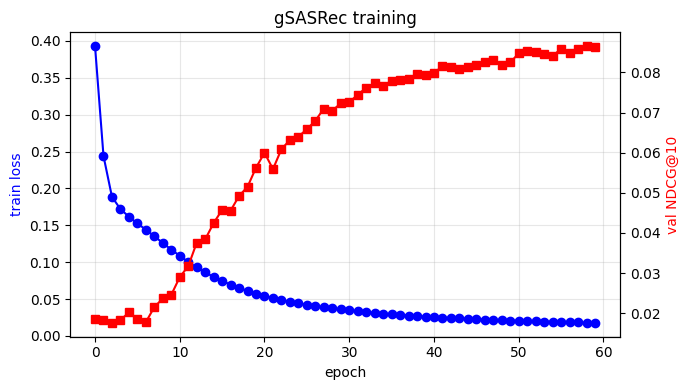

,epoch,train_loss,val_ndcg@10,epoch_seconds
55,55,0.018759,0.085924,0.58
56,56,0.018592,0.084844,0.58
57,57,0.018260,0.085851,0.58
58,58,0.017734,0.086548,0.58
59,59,0.017693,0.086316,0.58


In [15]:
import pandas as pd
import matplotlib.pyplot as plt


metrics = pd.read_csv(result['metrics_csv'])
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(metrics['epoch'], metrics['train_loss'], 'b-o', label='train loss')
ax2.plot(metrics['epoch'], metrics[f'val_ndcg@{cfg.eval_k}'], 'r-s', label=f'val NDCG@{cfg.eval_k}')
ax1.set_xlabel('epoch'); ax1.set_ylabel('train loss', color='b'); ax2.set_ylabel(f'val NDCG@{cfg.eval_k}', color='r')
ax1.grid(True, alpha=0.3)
plt.title('gSASRec training')
plt.tight_layout()
plt.show()
metrics.tail()

## 5. Sanity-check на test (per-user NDCG@10, не групповой)

Это диагностика скорера, не финальная оценка диплома (она групповая, Phase 2). Если test ≈ val — модель не переобучилась на val через early stopping.

In [16]:
from src.scorer.train import build_user_sequences, evaluate_ndcg

train_sequences = build_user_sequences(train, max_seq_len=cfg.max_seq_len)
test_targets = {
    int(uid): set(int(x) for x in g['item_idx'].to_numpy())
    for uid, g in test.groupby('uid', sort=False)
}
common = sum(1 for u in test_targets if u in train_sequences)
print(f'users in test: {len(test_targets)}, with train history: {common}')

test_ndcg = evaluate_ndcg(
    model,
    train_sequences=train_sequences,
    val_targets=test_targets,
    max_seq_len=cfg.max_seq_len,
    n_items=cfg.n_items,
    k=cfg.eval_k,
    batch_size=cfg.eval_batch_size,
    device=cfg.device,
)
print(f'test NDCG@{cfg.eval_k} = {test_ndcg:.4f}  (best val NDCG@{cfg.eval_k} = {result["best_ndcg"]:.4f})')

users in test: 4576, with train history: 4576
test NDCG@10 = 0.0726  (best val NDCG@10 = 0.0865)


## 6. Cache per-user top-K scores (Phase 1, Step I)

Прогоняем уже обученный gSASRec для всех train-пользователей и сохраняем топ-K кандидатов со скорами. Этот кэш используется в Phase 2 — групповые агрегаторы читают `s_{u,i}` отсюда, а не дёргают gSASRec на каждом батче.

Выход: `artifacts/user_scores_cache/scores.parquet` с колонками `uid:int64, item_idx:int64, score:float32, rank:int32`.

Эту секцию можно запускать отдельно после переобучения — `model`, `train_sequences`, `n_items`, `cfg.max_seq_len` уже в памяти.

In [ ]:
from src.scorer.inference import cache_user_scores, InferenceConfig

K = 200  # запас для Phase 2; агрегаторы будут резать по своим |C_G|
out_path = PROJECT_ROOT / 'artifacts' / 'user_scores_cache' / 'scores.parquet'

inf_cfg = InferenceConfig(K=K, batch_size=128, exclude_history=True, device=cfg.device)
cache_user_scores(model, train_sequences, cfg.max_seq_len, n_items, out_path, inf_cfg)
print('saved:', out_path)

In [ ]:
scores = pd.read_parquet(out_path)
print('rows:', len(scores))
print('users:', scores.uid.nunique())
print(f'K per user (should be {K}):', scores.groupby('uid').size().unique())
print('rank range:', scores['rank'].min(), '..', scores['rank'].max())
print('score range:', float(scores.score.min()), '..', float(scores.score.max()))
scores.head(10)